# Setup and Imports

In [1]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import glob
import os
from sklearn.cluster import DBSCAN

# Plotly might be slow with millions of points, so we will downsample
DOWNSAMPLE_RATE = 10

In [2]:
CLASS_MAPPING = {
    0: 'Unlabelled',
    1: 'Car',
    2: 'Truck',
    3: 'Bicycle',
    4: 'Pedestrian',
    5: 'Jersey Barrier',
    6: 'Guardrail'
}

COLOR_MAPPING = {
    'Unlabelled': 'lightgray',
    'Car': 'blue',
    'Truck': 'cyan',
    'Bicycle': 'orange',
    'Pedestrian': 'red',
    'Jersey Barrier': 'yellow',
    'Guardrail': 'green'
}

In [3]:
def load_pcd(filepath):
    try:
        df = pd.read_csv(filepath, sep=' ', skiprows=11, header=None, engine='c', 
                         names=['x', 'y', 'z', 'intensity', 'actor_id', 'class_id', 'material_id'])
        df = df.dropna(subset=['x', 'y', 'z'])
        return df
    except Exception as e:
        print(f"Error reading {filepath}: {e}")
        return None

In [4]:
def extract_bounding_boxes(df):
    boxes = []
    
    # Process labeled objects by actor_id
    labeled_df = df[df['class_id'] != 0]
    for actor_id, group in labeled_df.groupby('actor_id'):
        class_id = int(group['class_id'].iloc[0])
        class_name = CLASS_MAPPING.get(class_id, f'Unknown ({class_id})')
        label = f"{class_name} (Class {class_id}, Actor {int(actor_id)})"
        
        box = {
            'min_x': group['x'].min(), 'max_x': group['x'].max(),
            'min_y': group['y'].min(), 'max_y': group['y'].max(),
            'min_z': group['z'].min(), 'max_z': group['z'].max(),
            'label': label,
            'class_name': class_name
        }
        boxes.append(box)
        
    # Process unlabelled objects using DBSCAN to group disconnected components
    unlabeled_df = df[df['class_id'] == 0]
    if len(unlabeled_df) > 0:
        print(f"Clustering {len(unlabeled_df)} unlabelled points...")
        coords = unlabeled_df[['x', 'y', 'z']].values
        # Subsample for faster clustering if too large
        if len(coords) > 50000:
            sub_idx = np.random.choice(len(coords), 50000, replace=False)
            coords_sub = coords[sub_idx]
            clustering = DBSCAN(eps=1.0, min_samples=10).fit(coords_sub)
            labels = -np.ones(len(coords))
            labels[sub_idx] = clustering.labels_
        else:
            clustering = DBSCAN(eps=1.0, min_samples=10).fit(coords)
            labels = clustering.labels_
            
        unlabeled_df['cluster'] = labels
        for cluster_id, group in unlabeled_df[unlabeled_df['cluster'] != -1].groupby('cluster'):
            box = {
                'min_x': group['x'].min(), 'max_x': group['x'].max(),
                'min_y': group['y'].min(), 'max_y': group['y'].max(),
                'min_z': group['z'].min(), 'max_z': group['z'].max(),
                'label': "Unlabelled",
                'class_name': 'Unlabelled'
            }
            boxes.append(box)
            
    return boxes

In [5]:
def visualize_frame(df, boxes):
    fig = go.Figure()

    # Subsample points for rendering
    df_sub = df.iloc[::DOWNSAMPLE_RATE]
    
    # Map colors
    colors = [COLOR_MAPPING.get(CLASS_MAPPING.get(int(c), 'Unlabelled'), 'black') for c in df_sub['class_id']]

    # Add Point Cloud
    fig.add_trace(go.Scatter3d(
        x=df_sub['x'], y=df_sub['y'], z=df_sub['z'],
        mode='markers',
        marker=dict(size=1, color=colors, opacity=0.8),
        name='Points'
    ))

    # Add Bounding Boxes
    for box in boxes:
        color = COLOR_MAPPING.get(box['class_name'], 'black')
        
        # Define 8 corners of the box
        x_corners = [box['min_x'], box['max_x'], box['max_x'], box['min_x'], box['min_x'], box['max_x'], box['max_x'], box['min_x']]
        y_corners = [box['min_y'], box['min_y'], box['max_y'], box['max_y'], box['min_y'], box['min_y'], box['max_y'], box['max_y']]
        z_corners = [box['min_z'], box['min_z'], box['min_z'], box['min_z'], box['max_z'], box['max_z'], box['max_z'], box['max_z']]
        
        # Edges connecting the corners
        i = [0, 1, 2, 3, 0, 4, 5, 6, 7, 4, 0, 3, 7, 2, 6, 1, 5]
        j = [1, 2, 3, 0, 4, 5, 6, 7, 4, 0, 3, 7, 2, 6, 1, 5, 0] # Not standard format, using lines
        
        # Lines trace for bounding box
        x_lines = [box['min_x'], box['max_x'], box['max_x'], box['min_x'], box['min_x'], None,
                   box['min_x'], box['max_x'], box['max_x'], box['min_x'], box['min_x'], None,
                   box['min_x'], box['min_x'], None, box['max_x'], box['max_x'], None,
                   box['max_x'], box['max_x'], None, box['min_x'], box['min_x']]
        y_lines = [box['min_y'], box['min_y'], box['max_y'], box['max_y'], box['min_y'], None,
                   box['min_y'], box['min_y'], box['max_y'], box['max_y'], box['min_y'], None,
                   box['min_y'], box['min_y'], None, box['min_y'], box['min_y'], None,
                   box['max_y'], box['max_y'], None, box['max_y'], box['max_y']]
        z_lines = [box['min_z'], box['min_z'], box['min_z'], box['min_z'], box['min_z'], None,
                   box['max_z'], box['max_z'], box['max_z'], box['max_z'], box['max_z'], None,
                   box['min_z'], box['max_z'], None, box['min_z'], box['max_z'], None,
                   box['min_z'], box['max_z'], None, box['min_z'], box['max_z']]
                   
        fig.add_trace(go.Scatter3d(
            x=x_lines, y=y_lines, z=z_lines,
            mode='lines',
            line=dict(color=color, width=3),
            showlegend=False,
            hoverinfo='none'
        ))
        
        # Add label at the top center of the box
        center_x = (box['min_x'] + box['max_x']) / 2
        center_y = (box['min_y'] + box['max_y']) / 2
        
        fig.add_trace(go.Scatter3d(
            x=[center_x], y=[center_y], z=[box['max_z'] + 0.5],
            mode='text',
            text=[box['label']],
            textfont=dict(color=color, size=10),
            showlegend=False
        ))

    fig.update_layout(scene=dict(aspectmode='data'), title="Scenario Visualisation", margin=dict(l=0, r=0, b=0, t=30))
    fig.show()

Loading first frame: /Users/pavanreddy/Documents/MATLAB/LidarAnalysis/scripts/../lidar_dataset/Exported_PCD_Files_sangam_Final/frame_0001.pcd
Extracted 7 bounding boxes.


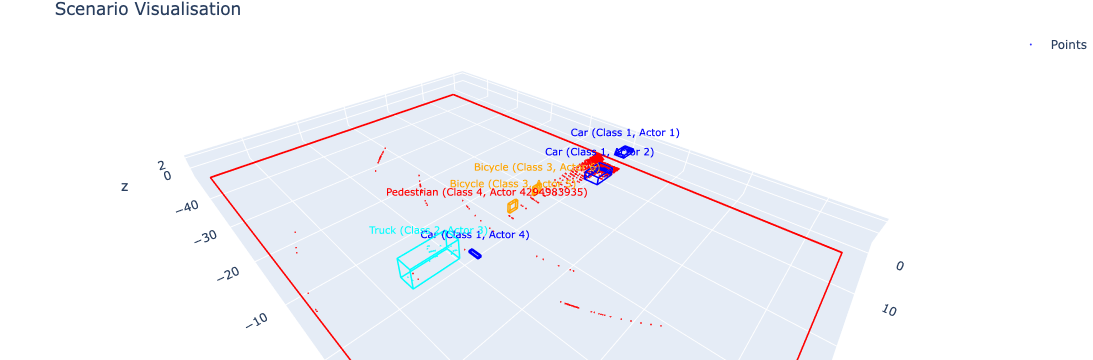

In [6]:
# Process Sangam Scenario
folder = '/Users/pavanreddy/Documents/MATLAB/LidarAnalysis/scripts/../lidar_dataset/Exported_PCD_Files_sangam_Final'
files = sorted(glob.glob(os.path.join(folder, '*.pcd')))

if files:
    print(f"Loading first frame: {files[0]}")
    df = load_pcd(files[0])
    
    if df is not None:
        boxes = extract_bounding_boxes(df)
        print(f"Extracted {len(boxes)} bounding boxes.")
        visualize_frame(df, boxes)
else:
    print("No PCD files found in the specified directory.")
